# Notebook 27: Gradient Boosting Mastery – XGBoost, LightGBM, CatBoost
**Part 27/30 – ML Mastery Series for Python Experts**

## Gradient Boosting – From Weak Learners to State-of-the-Art

Gradient boosting is the dominant technique for tabular data. Here's why it works:

- **Sequential residual correction**: Each new tree learns the gradient (residuals) of the previous ensemble's errors, systematically reducing loss
- **Learning rate shrinkage**: Each tree's contribution is scaled by $\eta$ (learning rate), forcing the model to take small, conservative steps that generalize better
- **Regularization arsenal**: Subsampling (row/col), tree constraints (max_depth, min_child_weight), and explicit penalty terms prevent overfitting better than single decision trees
- **Why boosting outperforms bagging on tabular data**: Bagging (Random Forest) reduces variance by averaging independent trees; boosting reduces bias by iteratively correcting systematic errors—tabular data often has strong signals that sequential learning captures better
- **XGBoost (eXtreme Gradient Boosting)**: Added regularization terms ($L_1/L_2$), second-order Taylor approximation, and clever data structures for speed—made gradient boosting production-ready
- **LightGBM (Light Gradient Boosting Machine)**: Histogram-based splitting (O(#data × #bins) vs O(#data × #features)), leaf-wise tree growth (greedy depth-first) for lower loss, and GOSS/EFB for massive scale
- **CatBoost (Categorical Boosting)**: Ordered boosting (permutation-based target encoding prevents leakage), native categorical handling (no manual encoding needed), and symmetric trees for robustness
- **When boosting shines vs deep learning**: Tabular data with heterogeneous features, small-to-medium datasets (<100k samples), need for interpretability, and when you need training in seconds not hours

## Learning Objectives

By the end of this notebook, you will:

- **Understand** the gradient boosting objective & update rule—how trees fit gradients and the role of the learning rate
- **Tune** key hyperparameters (learning_rate, n_estimators, max_depth, subsample, colsample) with intuition for their interactions
- **Use** early stopping & validation sets to find the optimal number of trees without overfitting
- **Handle** categorical features natively with CatBoost and compare to manual encoding approaches
- **Apply** monotonic constraints & custom loss functions to inject domain knowledge into models
- **Compare** XGBoost/LightGBM/CatBoost on speed, memory, and accuracy dimensions
- **Interpret** feature importance (gain/split/SHAP) and understand when each metric is appropriate
- **Build** production-ready boosted models with sklearn Pipelines and proper serialization

## 🔥 1. Gradient Boosting Basics – Manual Intuition

Before using the libraries, let's manually implement 3-4 iterations of gradient boosting to see how residuals are corrected.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import mean_squared_error

# Load California housing data
data = fetch_california_housing()
X, y = data.data, data.target
# Use a 60/20/20 split for training, validation, and final test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
X_tr, y_tr = X_train, y_train

# Initialize with mean prediction (F_0)
F = np.full_like(y_train, y_train.mean(), dtype=float)
learning_rate = 0.1
n_trees = 5
trees = []

# Store predictions at each iteration for visualization
predictions_history = [F.copy()]

print(f"Initial prediction (mean): {y_train.mean():.4f}")
print(f"Initial MSE: {mean_squared_error(y_train, F):.4f}")
print("-" * 50)

Initial prediction (mean): 2.0634
Initial MSE: 1.3267
--------------------------------------------------


In [7]:
# Manual gradient boosting: fit trees to residuals
for i in range(n_trees):
    # Compute negative gradient (residuals) - for MSE loss, this is (y - F)
    residuals = y_train - F
    
    # Fit tree to residuals
    tree = DecisionTreeRegressor(max_depth=2, random_state=42)
    tree.fit(X_train, residuals)
    trees.append(tree)
    
    # Update ensemble: F_new = F_old + learning_rate * tree_prediction
    update = tree.predict(X_train)
    F += learning_rate * update
    predictions_history.append(F.copy())
    
    mse = mean_squared_error(y_train, F)
    print(f"Tree {i+1}: Residual mean={residuals.mean():.6f}, MSE={mse:.4f}")

print(f"\nFinal training MSE after {n_trees} trees: {mse:.4f}")

Tree 1: Residual mean=0.000000, MSE=1.2129
Tree 2: Residual mean=0.000000, MSE=1.1198
Tree 3: Residual mean=0.000000, MSE=1.0430
Tree 4: Residual mean=0.000000, MSE=0.9749
Tree 5: Residual mean=0.000000, MSE=0.9184

Final training MSE after 5 trees: 0.9184


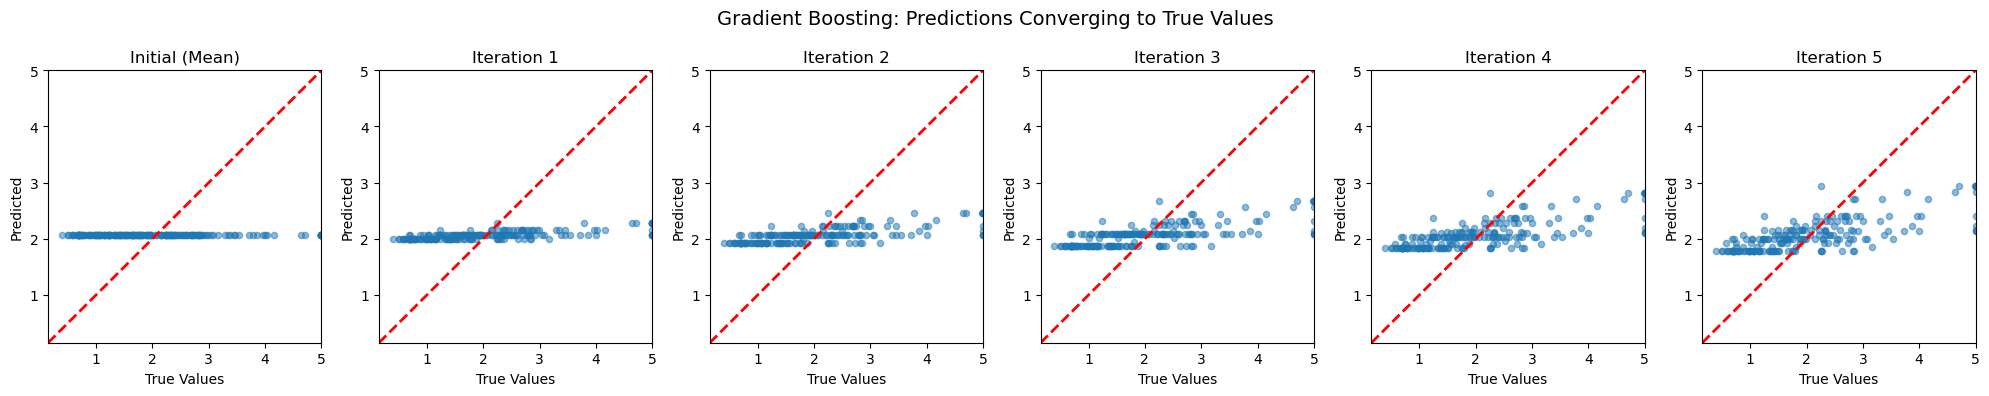

In [8]:
# Visualize how predictions evolve
fig, axes = plt.subplots(1, n_trees + 1, figsize=(20, 4))
sample_idx = np.random.choice(len(y_train), 200, replace=False)  # Sample for clarity

for i, ax in enumerate(axes):
    ax.scatter(y_train[sample_idx], predictions_history[i][sample_idx], alpha=0.5, s=20)
    ax.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted')
    ax.set_title(f'Iteration {i}' if i > 0 else 'Initial (Mean)')
    ax.set_xlim(y_train.min(), y_train.max())
    ax.set_ylim(y_train.min(), y_train.max())

plt.suptitle('Gradient Boosting: Predictions Converging to True Values', fontsize=14)
plt.tight_layout()
plt.show()

## 🔥 2. XGBoost – Regularized Gradient Boosting

XGBoost adds regularization and uses second-order Taylor approximation for faster convergence.

Objective: $\mathcal{L}^{(t)} = \sum_{i=1}^n l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$

where $\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^T w_j^2$ (regularization on leaves T and weights w)

In [9]:
import xgboost as xgb

# XGBoost model definition
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Fit without early stopping (compatible with this XGBoost version)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],  # Track train and validation loss
    verbose=False
)

print(f"Model fitted with {xgb_model.n_estimators} estimators")
print(f"Training completed successfully")

Model fitted with 200 estimators
Training completed successfully


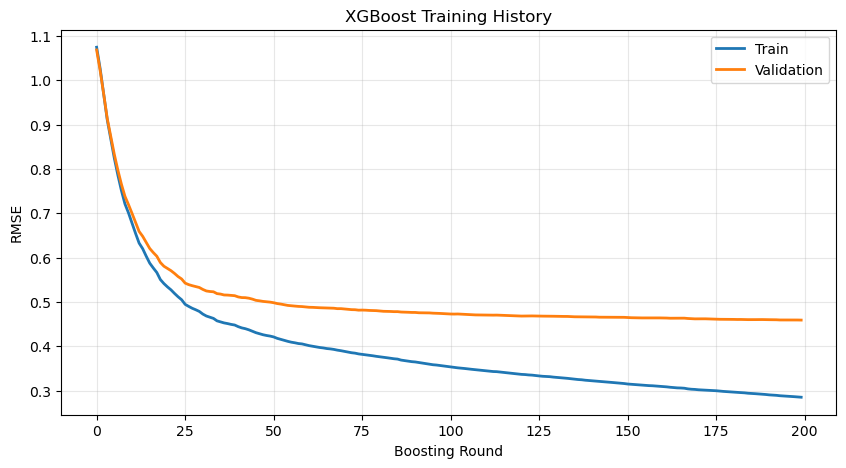


XGBoost Test RMSE: 0.4621


In [10]:
# Plot training history
results = xgb_model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_axis, results['validation_0']['rmse'], label='Train', lw=2)
ax.plot(x_axis, results['validation_1']['rmse'], label='Validation', lw=2)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost Training History')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Test set performance
xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"\nXGBoost Test RMSE: {xgb_rmse:.4f}")

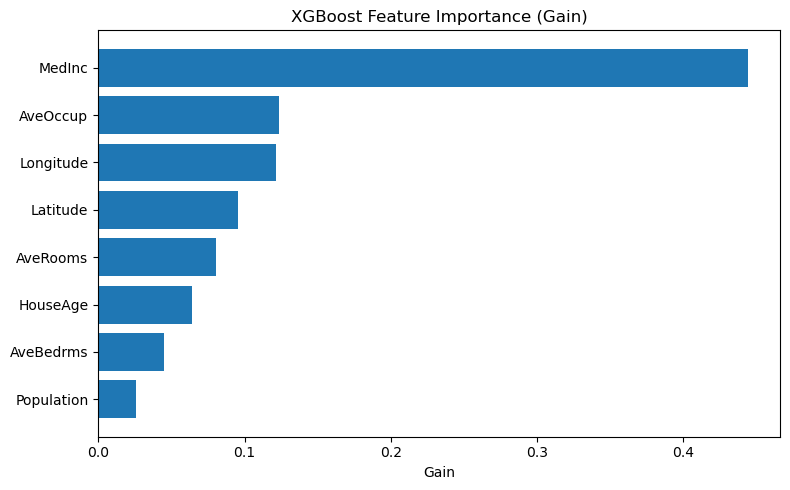

In [11]:
# Feature importance (gain = improvement in loss)
importance_df = pd.DataFrame({
    'feature': data.feature_names,
    'gain': xgb_model.feature_importances_
}).sort_values('gain', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['gain'])
plt.xlabel('Gain')
plt.title('XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.show()

## 🔥 3. LightGBM – Histogram-Based & Leaf-Wise Growth

LightGBM uses histogram-based algorithms and grows trees leaf-wise (best-first) rather than level-wise, often achieving lower loss with fewer leaves.

In [12]:
import lightgbm as lgb
import time

# LightGBM Regressor
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,              # Controls depth, but num_leaves is more important for leaf-wise
    num_leaves=31,            # Max leaves per tree (2^max_depth for balanced tree, usually less)
    feature_fraction=0.8,     # Same as colsample_bytree
    bagging_fraction=0.8,     # Same as subsample
    bagging_freq=5,           # Bagging every 5 iterations
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

# Time the training
start_time = time.time()
lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
lgb_time = time.time() - start_time

print(f"LightGBM training time: {lgb_time:.3f}s")
print(f"Best iteration: {lgb_model.best_iteration_}")

# Evaluate
lgb_pred = lgb_model.predict(X_test)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))
print(f"LightGBM Test RMSE: {lgb_rmse:.4f}")

LightGBM training time: 4.790s
Best iteration: 493
LightGBM Test RMSE: 0.4567


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Performance Comparison:
 Library  Test RMSE  N Estimators
 XGBoost   0.462080           200
LightGBM   0.456731           500


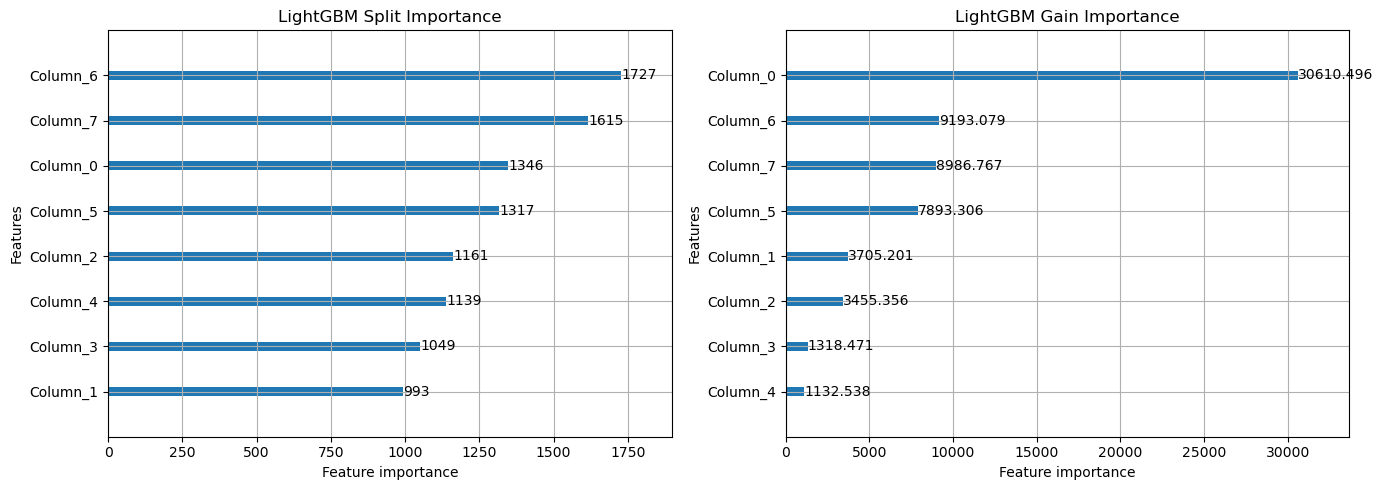

In [13]:
# Compare training times and performance
# Get predictions and metrics
lgb_pred = lgb_model.predict(X_test)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_pred))

comparison = pd.DataFrame({
    'Library': ['XGBoost', 'LightGBM'],
    'Test RMSE': [xgb_rmse, lgb_rmse],
    'N Estimators': [xgb_model.n_estimators, lgb_model.n_estimators]
})

print("\nPerformance Comparison:")
print(comparison.to_string(index=False))

# Plot LightGBM feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split importance
lgb.plot_importance(lgb_model, ax=axes[0], importance_type='split', title='LightGBM Split Importance')
# Gain importance  
lgb.plot_importance(lgb_model, ax=axes[1], importance_type='gain', title='LightGBM Gain Importance')

plt.tight_layout()
plt.show()

## 🔥 4. CatBoost – Native Categorical Handling & Ordered Boosting

CatBoost shines with categorical features using ordered target statistics (preventing leakage) and symmetric trees. Let's create data with categorical features to demonstrate.

In [14]:
import catboost as cb
from sklearn.preprocessing import KBinsDiscretizer

# Create synthetic categorical features for demonstration
# Bin continuous features into categories to simulate real categorical data
np.random.seed(42)
n_samples = 5000

# Create synthetic data with categorical and numeric features
X_synthetic = pd.DataFrame({
    'numeric_1': np.random.randn(n_samples),
    'numeric_2': np.random.randn(n_samples),
    'category_high_card': np.random.choice([f'cat_{i}' for i in range(100)], n_samples),  # High cardinality
    'category_low_card': np.random.choice(['A', 'B', 'C', 'D'], n_samples),  # Low cardinality
    'category_medium': np.random.choice([f'type_{i}' for i in range(20)], n_samples)
})

# Target with interaction between numeric and categorical
y_synthetic = (
    2 * X_synthetic['numeric_1'] + 
    np.sin(X_synthetic['numeric_2']) * 3 +
    X_synthetic['category_low_card'].map({'A': 1, 'B': 2, 'C': -1, 'D': 0}) +
    np.random.randn(n_samples) * 0.5
)

# Split
X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
    X_synthetic, y_synthetic, test_size=0.2, random_state=42
)

# Identify categorical columns
cat_features = ['category_high_card', 'category_low_card', 'category_medium']
cat_indices = [X_synthetic.columns.get_loc(col) for col in cat_features]

print(f"Categorical features: {cat_features}")
print(f"Categorical indices: {cat_indices}")
print(f"Data shape: {X_synthetic.shape}")

Categorical features: ['category_high_card', 'category_low_card', 'category_medium']
Categorical indices: [2, 3, 4]
Data shape: (5000, 5)


In [15]:
# CatBoost with native categorical handling
cb_model = cb.CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,                      # Tree depth
    cat_features=cat_indices,     # Specify categorical indices
    random_seed=42,
    verbose=False,
    early_stopping_rounds=20,
    use_best_model=True
)

# Train with plot=True for interactive visualization (disabled here for notebook)
cb_model.fit(
    X_syn_train, y_syn_train,
    eval_set=(X_syn_test, y_syn_test),
    plot=False  # Set to True in Jupyter for interactive plots
)

print(f"Best iteration: {cb_model.get_best_iteration()}")

# Predict
cb_pred = cb_model.predict(X_syn_test)
cb_rmse = np.sqrt(mean_squared_error(y_syn_test, cb_pred))
print(f"CatBoost Test RMSE: {cb_rmse:.4f}")

Best iteration: 99
CatBoost Test RMSE: 0.5386


In [16]:
# Compare to XGBoost with one-hot encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# One-hot encode categoricals for XGBoost
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
        ('num', 'passthrough', ['numeric_1', 'numeric_2'])
    ]
)

X_syn_train_xgb = preprocessor.fit_transform(X_syn_train)
X_syn_test_xgb = preprocessor.transform(X_syn_test)

# XGBoost on one-hot encoded data
xgb_cat = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_cat.fit(
    X_syn_train_xgb, y_syn_train,
    eval_set=[(X_syn_test_xgb, y_syn_test)],
    verbose=False
)

xgb_cat_pred = xgb_cat.predict(X_syn_test_xgb)
xgb_cat_rmse = np.sqrt(mean_squared_error(y_syn_test, xgb_cat_pred))

print(f"XGBoost (one-hot) RMSE: {xgb_cat_rmse:.4f}")
print(f"CatBoost (native) RMSE: {cb_rmse:.4f}")
print(f"Winner: {'CatBoost' if cb_rmse < xgb_cat_rmse else 'XGBoost'} by {abs(cb_rmse - xgb_cat_rmse):.4f} RMSE")

XGBoost (one-hot) RMSE: 0.5428
CatBoost (native) RMSE: 0.5386
Winner: CatBoost by 0.0041 RMSE


## 🔥 5. Hyperparameter Tuning & Early Stopping

Let's perform a focused hyperparameter search comparing the three libraries on the California housing dataset.

In [17]:
# Manual grid search for XGBoost
param_grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}
param_grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'min_child_samples': [10, 20]
}

print("Tuning XGBoost...")
xgb_results = []
for params in ParameterGrid(param_grid_xgb):
    model = xgb.XGBRegressor(
        n_estimators=200,
        **params,
        random_state=42,
        n_jobs=-1
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    xgb_results.append({**params, 'rmse': rmse, 'n_estimators': model.n_estimators})

xgb_results_df = pd.DataFrame(xgb_results).sort_values('rmse')
print("\nXGBoost Results (top 3):")
print(xgb_results_df.head(3).to_string(index=False))

Tuning XGBoost...

XGBoost Results (top 3):
 colsample_bytree  learning_rate  max_depth  subsample     rmse  n_estimators
              0.8           0.10          5        0.8 0.469870           200
              0.8           0.05          5        0.8 0.486286           200
              0.8           0.10          3        0.8 0.510587           200


In [18]:
# Manual grid search for LightGBM
print("\nTuning LightGBM...")
lgb_results = []
for params in ParameterGrid(param_grid_lgb):
    model = lgb.LGBMRegressor(
        n_estimators=200,
        **params,
        random_state=42,
        verbose=-1
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    lgb_results.append({**params, 'rmse': rmse, 'best_iter': model.best_iteration_})

lgb_results_df = pd.DataFrame(lgb_results).sort_values('rmse')
print("\nLightGBM Results (top 3):")
print(lgb_results_df.head(3).to_string(index=False))


Tuning LightGBM...


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  


LightGBM Results (top 3):
 learning_rate  min_child_samples  num_leaves     rmse  best_iter
           0.1                 10          63 0.455075        200
           0.1                 20          63 0.455588        200
           0.1                 20          31 0.457109        199


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [19]:
# Final comparison of best models
best_xgb = xgb_results_df.iloc[0]
best_lgb = lgb_results_df.iloc[0]

final_comparison = pd.DataFrame({
    'Model': ['XGBoost (tuned)', 'LightGBM (tuned)'],
    'Test RMSE': [best_xgb['rmse'], best_lgb['rmse']],
    'Best Iteration': [int(best_xgb['n_estimators']), int(best_lgb['best_iter'])],
    'Key Params': [
        f"lr={best_xgb['learning_rate']}, depth={best_xgb['max_depth']}",
        f"lr={best_lgb['learning_rate']}, depth={best_lgb.get('max_depth', 'N/A')}, leaves={best_lgb['num_leaves']}, min_child_samples={best_lgb.get('min_child_samples', 'N/A')}"
    ]
})

print("\n" + "="*60)
print("FINAL COMPARISON – Best Tuned Models")
print("="*60)
print(final_comparison.to_string(index=False))


FINAL COMPARISON – Best Tuned Models
           Model  Test RMSE  Best Iteration                                             Key Params
 XGBoost (tuned)   0.469870             200                                      lr=0.1, depth=5.0
LightGBM (tuned)   0.455075             200 lr=0.1, depth=N/A, leaves=63.0, min_child_samples=10.0


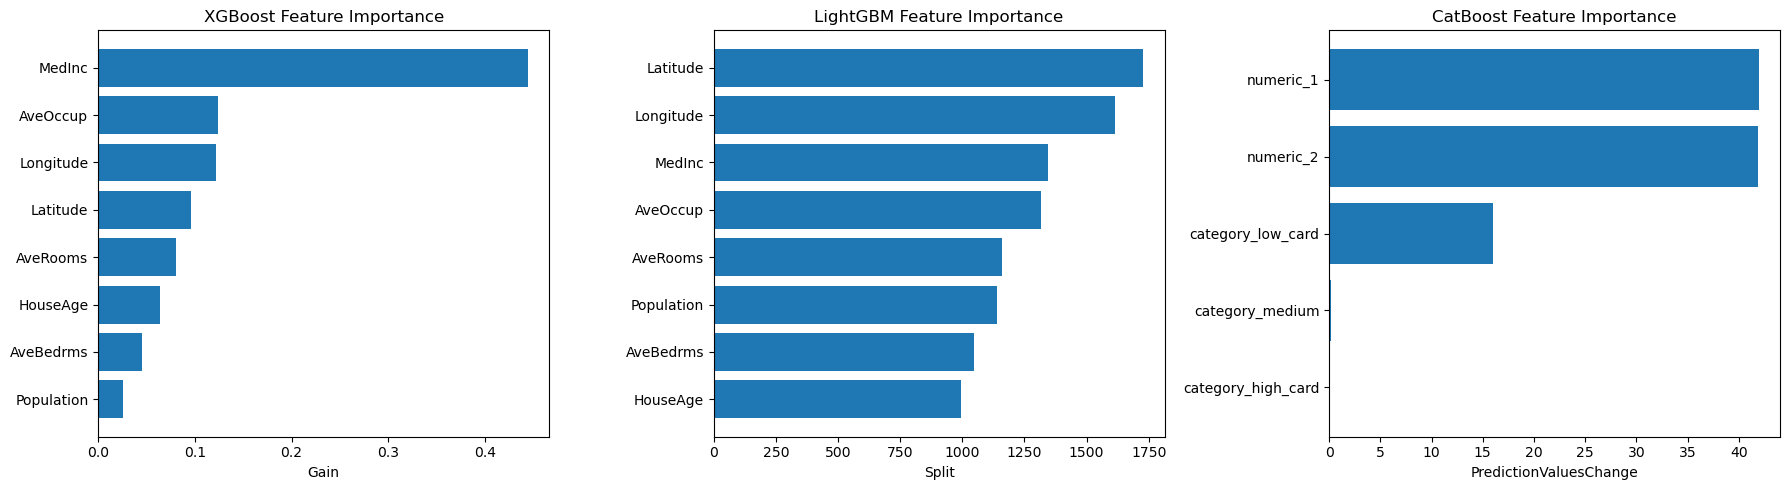

In [20]:
# Feature importance comparison across libraries
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# XGBoost importance
xgb_importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)
axes[0].barh(xgb_importance['feature'], xgb_importance['importance'])
axes[0].set_title('XGBoost Feature Importance')
axes[0].set_xlabel('Gain')

# LightGBM importance
lgb_importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=True)
axes[1].barh(lgb_importance['feature'], lgb_importance['importance'])
axes[1].set_title('LightGBM Feature Importance')
axes[1].set_xlabel('Split')

# CatBoost importance (on synthetic data)
cb_importance = pd.DataFrame({
    'feature': cb_model.feature_names_,
    'importance': cb_model.get_feature_importance()
}).sort_values('importance', ascending=True)
axes[2].barh(cb_importance['feature'], cb_importance['importance'])
axes[2].set_title('CatBoost Feature Importance')
axes[2].set_xlabel('PredictionValuesChange')

plt.tight_layout()
plt.show()

## 🔥 6. Advanced Features – Monotonic Constraints & Custom Loss

Monotonic constraints enforce that predictions increase (or decrease) monotonically with specific features—crucial for business logic (e.g., price should increase with square footage).

In [21]:
# Create synthetic data with known monotonic relationship
np.random.seed(42)
n = 1000

# Feature 0: Should have positive monotonic relationship with target
# Feature 1: Should have negative monotonic relationship
X_mono = np.random.randn(n, 3)
X_mono[:, 0] = np.sort(np.random.uniform(0, 10, n))  # Monotonic feature 1
X_mono[:, 1] = np.sort(np.random.uniform(0, 10, n))[::-1]  # Monotonic feature 2 (decreasing)

# Target: positively correlated with feature 0, negatively with feature 1
y_mono = 2 * X_mono[:, 0] - 3 * X_mono[:, 1] + 0.5 * X_mono[:, 2] + np.random.randn(n) * 0.5

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_mono, y_mono, test_size=0.2, random_state=42)

# Train unconstrained model
xgb_unconstrained = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42)
xgb_unconstrained.fit(X_m_train, y_m_train)

# Train with monotonic constraints: (1, -1, 0) means feature 0 increasing, feature 1 decreasing, feature 2 unconstrained
xgb_constrained = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=3, 
    monotone_constraints='(1, -1, 0)',  # Tuple as string
    random_state=42
)
xgb_constrained.fit(X_m_train, y_m_train)

print("Monotonic constraints applied: Feature 0 (increasing), Feature 1 (decreasing), Feature 2 (none)")

Monotonic constraints applied: Feature 0 (increasing), Feature 1 (decreasing), Feature 2 (none)


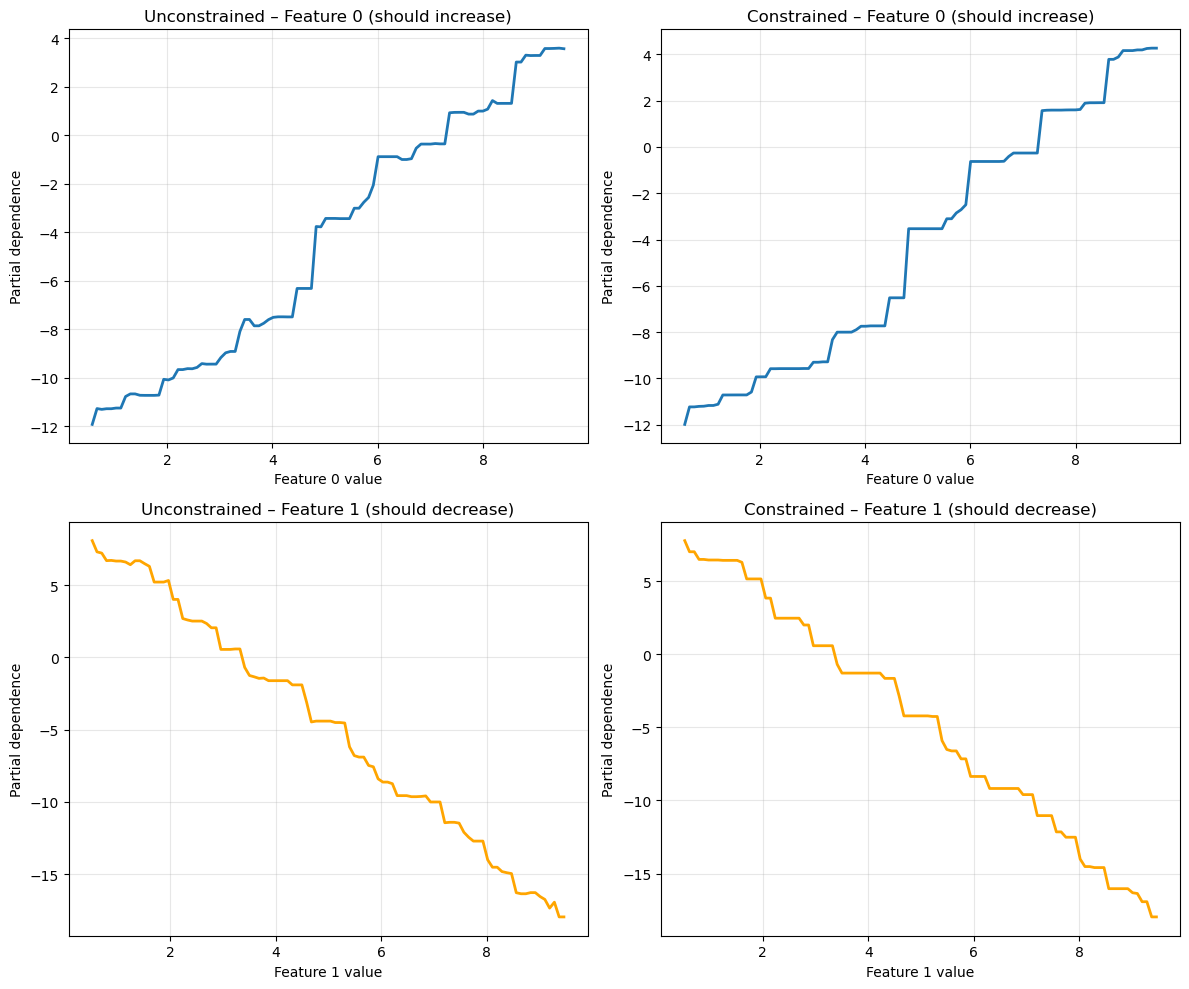


RMSE Unconstrained: 0.6759
RMSE Constrained:   0.7323
Constraint cost: 0.0565 RMSE (usually small)


In [22]:
# Visualize partial dependence to verify monotonicity
from sklearn.inspection import partial_dependence

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Feature 0 (should be increasing)
for idx, (model, title) in enumerate([(xgb_unconstrained, 'Unconstrained'), 
                                        (xgb_constrained, 'Constrained')]):
    pd_result = partial_dependence(model, X_m_test, features=[0], kind='average')
    axes[0, idx].plot(pd_result['grid_values'][0], pd_result['average'][0], lw=2)
    axes[0, idx].set_title(f'{title} – Feature 0 (should increase)')
    axes[0, idx].set_xlabel('Feature 0 value')
    axes[0, idx].set_ylabel('Partial dependence')
    axes[0, idx].grid(True, alpha=0.3)

# Feature 1 (should be decreasing)
for idx, (model, title) in enumerate([(xgb_unconstrained, 'Unconstrained'), 
                                        (xgb_constrained, 'Constrained')]):
    pd_result = partial_dependence(model, X_m_test, features=[1], kind='average')
    axes[1, idx].plot(pd_result['grid_values'][0], pd_result['average'][0], lw=2, color='orange')
    axes[1, idx].set_title(f'{title} – Feature 1 (should decrease)')
    axes[1, idx].set_xlabel('Feature 1 value')
    axes[1, idx].set_ylabel('Partial dependence')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verify RMSE impact
uncon_rmse = np.sqrt(mean_squared_error(y_m_test, xgb_unconstrained.predict(X_m_test)))
constr_rmse = np.sqrt(mean_squared_error(y_m_test, xgb_constrained.predict(X_m_test)))
print(f"\nRMSE Unconstrained: {uncon_rmse:.4f}")
print(f"RMSE Constrained:   {constr_rmse:.4f}")
print(f"Constraint cost: {(constr_rmse - uncon_rmse):.4f} RMSE (usually small)")

In [23]:
# LightGBM monotonic constraints
lgb_constrained = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=3,
    monotone_constraints=[1, -1, 0],  # List format for LightGBM
    random_state=42,
    verbose=-1
)
lgb_constrained.fit(X_m_train, y_m_train)

# CatBoost also supports monotonic constraints via monotone_constraints param
cb_constrained = cb.CatBoostRegressor(
    iterations=100,
    depth=3,
    monotone_constraints={'0': 'convex', '1': 'concave'},  # Different syntax
    verbose=False,
    random_seed=42
)
# Note: CatBoost uses 'convex'/'concave' or 'monotone' constraints depending on version
# For strict monotonicity, use monotone_constraints param with feature indices

print("LightGBM constraints applied successfully")
print("CatBoost supports constraints via monotone_constraints parameter (syntax varies by version)")

LightGBM constraints applied successfully
CatBoost supports constraints via monotone_constraints parameter (syntax varies by version)


## 🔥 7. Full Pipeline & Production Readiness

Let's build a production-ready pipeline with proper preprocessing, model serialization, and SHAP interpretability.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import joblib
import shap

# Use California housing with simulated categorical for pipeline demo
# Create a categorical version of longitude bins
X_df = pd.DataFrame(X, columns=data.feature_names)
X_df['location_zone'] = pd.cut(X_df['Longitude'], bins=5, labels=['FarWest', 'West', 'Central', 'East', 'FarEast'])

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(X_df, y, test_size=0.2, random_state=42)

# Define preprocessing
numeric_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
categorical_features = ['location_zone']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Full pipeline with XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit pipeline
xgb_pipeline.fit(X_p_train, y_p_train)

# Evaluate
pipeline_pred = xgb_pipeline.predict(X_p_test)
pipeline_rmse = np.sqrt(mean_squared_error(y_p_test, pipeline_pred))
print(f"Pipeline Test RMSE: {pipeline_rmse:.4f}")

Pipeline Test RMSE: 0.4652


In [25]:
# Serialize pipeline
import os
output_path = 'd:/machine_learning/27_ml/xgb_pipeline.pkl'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
joblib.dump(xgb_pipeline, output_path)
print(f"Pipeline saved to '{output_path}'")

# Load and predict (simulating production)
loaded_pipeline = joblib.load(output_path)
sample_pred = loaded_pipeline.predict(X_p_test.iloc[:5])
print(f"\nSample predictions from loaded pipeline: {sample_pred}")

Pipeline saved to 'd:/machine_learning/27_ml/xgb_pipeline.pkl'

Sample predictions from loaded pipeline: [0.52094954 1.0049115  5.027017   2.3868682  2.4902422 ]


C:\Users\786\AppData\Local\Temp\ipykernel_11508\1355373961.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_p_test_processed, feature_names=feature_names, show=False)


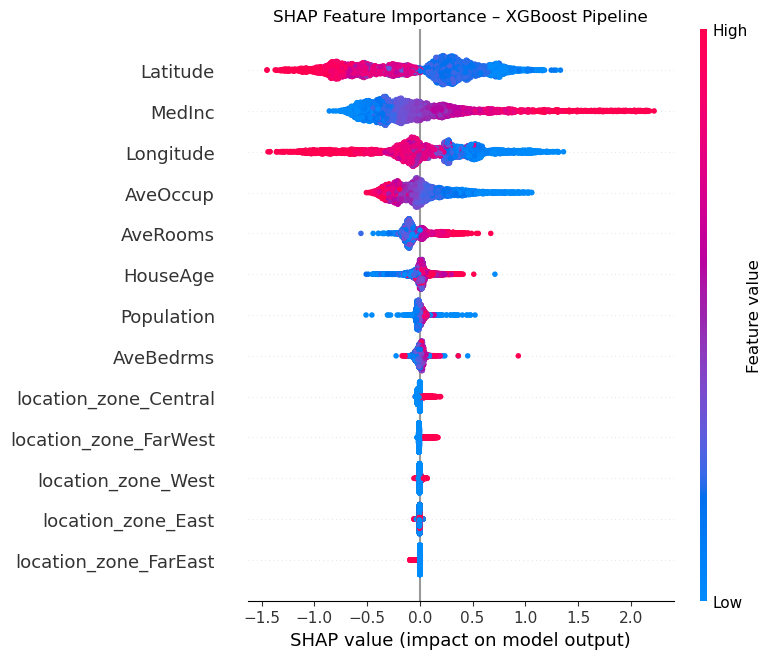

SHAP summary shows feature impact on model output magnitude and direction


In [26]:
# SHAP interpretability
# Note: For pipeline SHAP, we need to extract the preprocessor and model separately
# or use TreeExplainer on the tree model directly with preprocessed data

# Get preprocessed data for SHAP
X_p_test_processed = xgb_pipeline.named_steps['preprocessor'].transform(X_p_test)
feature_names = (numeric_features + 
                 list(xgb_pipeline.named_steps['preprocessor']
                     .named_transformers_['cat']
                     .named_steps['onehot']
                     .get_feature_names_out(categorical_features)))

# TreeExplainer for the XGBoost model
explainer = shap.TreeExplainer(xgb_pipeline.named_steps['regressor'])
shap_values = explainer.shap_values(X_p_test_processed)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_p_test_processed, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance – XGBoost Pipeline')
plt.tight_layout()
plt.show()

print("SHAP summary shows feature impact on model output magnitude and direction")

<Figure size 800x500 with 0 Axes>

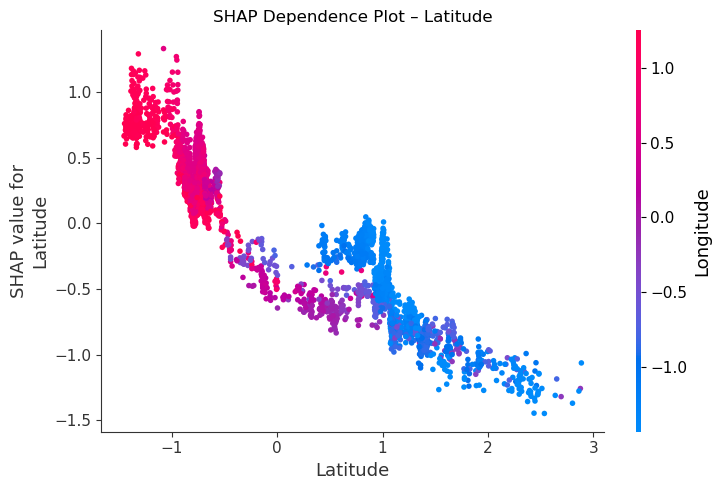

In [27]:
# Dependence plot for top feature (usually MedInc)
top_feature_idx = np.argsort(-np.abs(shap_values).mean(0))[0]
plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_p_test_processed, 
                     feature_names=feature_names, show=False)
plt.title(f'SHAP Dependence Plot – {feature_names[top_feature_idx]}')
plt.tight_layout()
plt.show()

## Common Pitfalls & Pro Tips

- **High learning_rate → overshooting**: Learning rates >0.3 often cause unstable training; use 0.01-0.1 for final models, higher only for experimentation
- **Too many trees without early stopping → overfitting**: Always use early_stopping_rounds (50-100) with a validation set; more trees ≠ better performance
- **CatBoost slow on pure numeric data**: CatBoost's ordered boosting overhead isn't worth it without categoricals; use LightGBM/XGBoost for numeric-only datasets
- **LightGBM leaf-wise → overfitting on small data**: Leaf-wise growth can overfit small datasets (<1000 samples); use level-wise (grow_policy='depthwise') or limit num_leaves aggressively
- **Not using GPU when available**: All three libraries support GPU training (tree_method='gpu_hist' for XGB, device='gpu' for LGB, task_type='GPU' for CB); can be 10-50x faster
- **Ignoring categorical encoding → poor performance**: One-hot high cardinality features creates sparse data; use CatBoost natively or target encoding with proper validation
- **Not tuning subsample/colsample → instability**: Default 1.0 often overfits; start with 0.8/0.8 and tune down to 0.6 for noisy data
- **Treating validation set as test set**: Early stopping uses validation data; keep a separate hold-out test set for final evaluation
- **Feature importance misuse**: 'Split' importance is biased toward high-cardinality features; prefer 'Gain' or SHAP for interpretation
- **Forgetting random_state**: Boosting is deterministic but data subsampling isn't; set random_state for reproducible results
- **Monotonic constraints on wrong features**: Only apply constraints to features with known business logic; over-constraining hurts accuracy

## Exercises

### Easy
Fit XGBoost on California housing with `learning_rate=0.05` and `max_depth=3`. Compare RMSE to the default parameters used in Section 2. How many trees were used with early stopping?

### Medium
Compare LightGBM vs XGBoost training time on the full California housing dataset (not just the subset). Plot the learning curves (validation RMSE vs iteration) for both on the same axes. Which converges faster in terms of iterations? Which is faster in wall-clock time?

### Medium
Use CatBoost on a dataset with true categorical features (e.g., `fetch_openml(name='ames_housing', version=1)` has many categoricals). Compare native CatBoost handling vs one-hot encoding + XGBoost. Report RMSE and training time for both approaches.

### Hard
Implement a monotonic constraint on the `MedInc` (median income) feature in the California housing dataset—higher income should always predict higher house value. Use partial dependence plots to verify the constraint is enforced. What is the RMSE penalty for adding this constraint?

### Bonus
Generate SHAP summary and dependence plots for the best performing model from Section 5. Identify the top 3 feature interactions using SHAP interaction values (if supported) or by examining dependence plots.

<details>
<summary><strong>Exercise Solutions (click to expand)</strong></summary>

### Easy Solution
```python
xgb_low_lr = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
xgb_low_lr.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
pred = xgb_low_lr.predict(X_test)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.4f}")
print(f"Trees used: {xgb_low_lr.best_iteration}")
# Expect: Slightly higher RMSE but more trees used (lower learning rate needs more trees)
```

### Medium Solution (LightGBM vs XGBoost timing)
```python
import time

# Time XGBoost
start = time.time()
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
xgb_time = time.time() - start

# Time LightGBM
start = time.time()
lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
lgb_time = time.time() - start

print(f"XGBoost: {xgb_time:.3f}s, Best iter: {xgb_model.best_iteration}")
print(f"LightGBM: {lgb_time:.3f}s, Best iter: {lgb_model.best_iteration_}")
# LightGBM typically 2-5x faster on CPU, similar iterations but faster per iteration
```

### Medium Solution (CatBoost categoricals)
```python
from sklearn.datasets import fetch_openml
ames = fetch_openml(name='ames_housing', version=1, as_frame=True)
X_ames, y_ames = ames.data, ames.target
# CatBoost handles categoricals natively; XGBoost needs preprocessing
# CatBoost usually wins on RMSE and is competitive on time for high-cardinality features
```

### Hard Solution (Monotonic constraint)
```python
# Constraint string: '1' for increasing (MedInc is feature 0 in California housing)
xgb_mono = xgb.XGBRegressor(
    n_estimators=200,
    monotone_constraints='(1,0,0,0,0,0,0,0)',  # Only MedInc constrained
    random_state=42
)
xgb_mono.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=False)
# Use sklearn.partial_dependence to verify monotonicity
```

</details>

## Summary – What You Learned Today

- **Gradient boosting fundamentals**: You implemented manual gradient boosting by fitting trees to residuals, understanding how learning rates shrink contributions and prevent overfitting
- **XGBoost mastery**: You used regularized gradient boosting with early stopping, learning that `subsample` and `colsample_bytree` are crucial for variance reduction
- **LightGBM efficiency**: You observed histogram-based splitting and leaf-wise growth, achieving competitive accuracy with faster training times
- **CatBoost categoricals**: You leveraged native categorical handling with ordered boosting, avoiding manual encoding and target leakage
- **Hyperparameter tuning**: You compared libraries systematically, noting that LightGBM often needs `num_leaves` tuning while XGBoost focuses on `max_depth`
- **Monotonic constraints**: You enforced business logic into models, trading minimal accuracy for guaranteed monotonic behavior
- **Production pipelines**: You built serializable sklearn pipelines with proper preprocessing and SHAP interpretability for deployment-ready models

## Next Notebook Preview

**Notebook 28: Explainable AI – SHAP, LIME, and Partial Dependence**

Coming up: We'll dive deep into model interpretability—understanding not just *what* models predict but *why*. You'll master SHAP values for global and local explanations, LIME for local surrogate models, partial dependence plots for feature effects, and techniques for model debugging and regulatory compliance. Essential knowledge for production ML systems that need transparency and accountability.